# 06) Test -- Final Validation

Final out-of-sample validation for the winning recipe decided in `05)`: **MLP model, quintile
long/short buckets, 15:58:00 entry**. `15:55:00` was ruled out there (its Sharpe flips negative
under any execution lag), and within `15:58:00`, MLP + quintile was the chosen combination.

This notebook is deliberately separate from `05)`: it runs the identical backtest methodology
against **both** the 17-day train period (`data/train.csv`, 2025-03-03 to 2025-03-25, walk-forward
as before) **and** the 4-day held-out test period (`data/test.csv`, 2025-03-26 to 2025-03-31, never
touched by any prior notebook) -- so the test numbers at the end are a genuine first look, not a
number that's been implicitly tuned against.

One fix carried over from `04)` but not yet applied in `05)`: the MLP's early stopping here uses an
inner train/val split, not the outer eval fold -- `05)`'s copy of `train_one_fold_torch` still has
that leak. This notebook's MLP training is leak-free.

## Setup

In [1]:
import json
import tarfile

import numpy as np
import pandas as pd
from scipy import stats as sstats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

train_df = pd.read_csv("data/train.csv", parse_dates=["date"])
test_df = pd.read_csv("data/test.csv", parse_dates=["date"])
with open("data/columns.json") as f:
    columns = json.load(f)

TARGET_COL = columns["target_cols"][0]
FINAL_FEATURE_COLS = columns["final_feature_cols"]

with open("best_hyperparameters.json") as f:
    best_hyperparameters = json.load(f)
mlp_params = best_hyperparameters["mlp"]

full_df = pd.concat([train_df, test_df], ignore_index=True)
print(f"train_df: {train_df.shape[0]} rows ({train_df['date'].nunique()} days), "
      f"test_df: {test_df.shape[0]} rows ({test_df['date'].nunique()} days)")
print(f"train dates: {train_df['date'].min().date()} to {train_df['date'].max().date()}")
print(f"test dates:  {test_df['date'].min().date()} to {test_df['date'].max().date()}")

train_df: 8443 rows (17 days), test_df: 1987 rows (4 days)
train dates: 2025-03-03 to 2025-03-25
test dates:  2025-03-26 to 2025-03-31


## Raw intraday loader + 15:58:00 snapshot panel

Same reconstruction as `05)`, but built once over the combined train+test universe so the same
panel-building logic (and the same realized-P&L convention -- long leg priced off `ask`, short leg
off `bid`, both exiting via a guaranteed-fill MOC order at `close_price`) applies identically to
both periods. Split into `train_panel`/`test_panel` by date after building.

In [2]:
def load_raw_intraday(tar_path, valid_keys):
    frames = []
    with tarfile.open(tar_path) as tf:
        for member in tf.getmembers():
            if not member.name.endswith(".csv.gz"):
                continue
            date_str = member.name.split(".")[0]
            d = pd.read_csv(tf.extractfile(member), compression="gzip")
            d = d.drop(columns=["ts.1"])
            d["date"] = pd.to_datetime(date_str, format="%Y%m%d")
            d = d.merge(valid_keys, on=["symbol", "date"], how="inner")
            if len(d):
                frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df["ts"] = pd.to_datetime(df["ts"])
    df["local_clock"] = df["local_time"].str.slice(11, 19)
    return df


valid_keys = full_df[["symbol", "date"]].drop_duplicates()
raw = load_raw_intraday("data/202503_imbalance.tar", valid_keys)
print(f"raw intraday rows (train+test universe): {raw.shape[0]}")

raw intraday rows (train+test universe): 4079904


In [3]:
def add_realized_pnl_cols(df):
    # Realized P&L if actually traded: cross the spread to enter -- buy at ask on a
    # predicted-buy row, sell short at bid on a predicted-sell row -- then exit both via
    # a guaranteed-fill MOC order at close_price. See 02)'s Target section.
    df = df.copy()
    df["realized_buy_bps"] = (df["close_price"] / df["ask"] - 1) * 1e4
    df["realized_sell_bps"] = (1 - df["close_price"] / df["bid"]) * 1e4
    return df


def build_snapshot_panel(raw, cutoff_clock, keys_df):
    sl = raw[raw["local_clock"] <= cutoff_clock]
    snap = sl.sort_values("ts").groupby(["symbol", "date"]).tail(1).copy()
    keys = keys_df[["symbol", "date", "close_price"]].drop_duplicates()
    panel = snap.merge(keys, on=["symbol", "date"], how="inner")

    panel["signed_shares"] = np.where(panel["side"] == "BUY", panel["shares"],
                                np.where(panel["side"] == "SELL", -panel["shares"], 0.0))
    panel["signed_imbalance_ratio"] = panel["signed_shares"] / (panel["paired_shares"] + panel["shares"])
    panel["spread_bps"] = (panel["ask"] - panel["bid"]) / panel["ref_price"] * 1e4
    panel["urgency"] = panel["signed_imbalance_ratio"] * panel["spread_bps"]

    mid = (panel["bid"] + panel["ask"]) / 2
    near_available = panel["near_price"] != 0
    far_available = panel["far_price"] != 0
    panel["near_price_vs_mid_bps"] = np.where(near_available, (panel["near_price"] / mid - 1) * 1e4, np.nan)
    panel["far_price_vs_mid_bps"] = np.where(far_available, (panel["far_price"] / mid - 1) * 1e4, np.nan)
    panel["ref_price_vs_mid_bps"] = (panel["ref_price"] / mid - 1) * 1e4

    panel[TARGET_COL] = (panel["close_price"] / mid - 1) * 1e4
    panel = add_realized_pnl_cols(panel)

    cols = ["date", "symbol"] + FINAL_FEATURE_COLS + [TARGET_COL, "realized_buy_bps", "realized_sell_bps"]
    panel = panel[cols]

    n_before = len(panel)
    panel = panel[np.isfinite(panel[TARGET_COL]) & np.isfinite(panel["realized_buy_bps"])
                  & np.isfinite(panel["realized_sell_bps"])]
    n_dropped = n_before - len(panel)
    if n_dropped:
        print(f"  dropped {n_dropped} row(s) with a non-finite target (missing bid/ask at snapshot)")
    return panel.reset_index(drop=True)


PANEL_58 = build_snapshot_panel(raw, "15:58:00", full_df)
train_dates = train_df["date"].unique()
test_dates = test_df["date"].unique()
train_panel = PANEL_58[PANEL_58["date"].isin(train_dates)].reset_index(drop=True)
test_panel = PANEL_58[PANEL_58["date"].isin(test_dates)].reset_index(drop=True)
print(f"train_panel: {train_panel.shape[0]} rows | test_panel: {test_panel.shape[0]} rows")

train_panel: 8443 rows | test_panel: 1987 rows


## MLP model + backtest engine

`train_mlp` carves an inner 90/10 train/val split out of the fit data for early stopping and seeds
`torch` -- the eval/test fold is never touched until the final prediction, unlike `05)`'s copy.

`bucket_trades` returns **per-name rows**, not just the daily aggregate -- every stock selected
into the long or short quintile leg, tagged with its own realized P&L. This is what the stress
tests below operate on; `trades_to_daily` collapses it to the one-row-per-day portfolio return used
for Sharpe/t-stats/hit rate.

In [4]:
ACTIVATIONS = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU}


class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_layer_sizes, activation):
        super().__init__()
        act_cls = ACTIVATIONS[activation]
        layers = []
        prev_size = input_dim
        for size in hidden_layer_sizes:
            layers.append(nn.Linear(prev_size, size))
            layers.append(act_cls())
            prev_size = size
        layers.append(nn.Linear(prev_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(X_fit, y_fit, hidden_layer_sizes, activation, alpha, learning_rate_init,
              max_epochs=200, patience=20):
    torch.manual_seed(0)
    device = torch.device("cpu")
    X_train, X_val, y_train, y_val = train_test_split(X_fit, y_fit, test_size=0.1, random_state=0)
    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)

    model = MLPNet(X_fit.shape[1], tuple(hidden_layer_sizes), activation).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate_init, weight_decay=alpha)
    loss_fn = nn.MSELoss()

    best_val_mse = float("inf")
    best_state = None
    epochs_without_improvement = 0
    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_mse = loss_fn(model(X_val_t), y_val_t).item()

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    return model


def predict_mlp(model, X):
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy()


print("MLPNet, train_mlp, predict_mlp ready")

MLPNet, train_mlp, predict_mlp ready


In [5]:
QUINTILE_FRAC = 0.20


def bucket_trades(eval_df, pred_col, buy_col, sell_col, frac=QUINTILE_FRAC):
    n = len(eval_df)
    n_bucket = max(1, int(round(n * frac)))
    ranked = eval_df.sort_values(pred_col, ascending=False)
    long_leg = ranked.iloc[:n_bucket][["date", "symbol", buy_col]].rename(columns={buy_col: "pnl_bps"})
    long_leg["leg"] = "long"
    short_leg = ranked.iloc[-n_bucket:][["date", "symbol", sell_col]].rename(columns={sell_col: "pnl_bps"})
    short_leg["leg"] = "short"
    return pd.concat([long_leg, short_leg], ignore_index=True)


def trades_to_daily(trades_df):
    daily = trades_df.groupby(["date", "leg"])["pnl_bps"].mean().unstack("leg")
    daily["daily_return_bps"] = daily.get("long", 0) + daily.get("short", 0)
    return daily.reset_index()[["date", "daily_return_bps"]]


def build_folds(panel_df, min_train_days=1, delta_days=1):
    unique_dates = np.sort(panel_df["date"].unique())
    folds = []
    for eval_start in range(min_train_days, len(unique_dates), delta_days):
        fit_dates = unique_dates[:eval_start]
        eval_dates = unique_dates[eval_start:eval_start + delta_days]
        fit_mask = panel_df["date"].isin(fit_dates)
        eval_mask = panel_df["date"].isin(eval_dates)
        folds.append((fit_mask, eval_mask))
    return folds


print("bucket_trades, trades_to_daily, build_folds ready")

bucket_trades, trades_to_daily, build_folds ready


## Train backtest -- walk-forward (same methodology as `05)`)

Expanding window over the 17 train days: retrain the MLP on every day up to T, predict day T+1,
form the quintile buckets, repeat. 16 out-of-sample days.

In [6]:
def run_walkforward_backtest(panel_df):
    all_trades = []
    for fold_idx, (fit_mask, eval_mask) in enumerate(build_folds(panel_df)):
        X_fit_raw = panel_df.loc[fit_mask, FINAL_FEATURE_COLS].to_numpy()
        y_fit = panel_df.loc[fit_mask, TARGET_COL].to_numpy()
        X_eval_raw = panel_df.loc[eval_mask, FINAL_FEATURE_COLS].to_numpy()

        imputer = SimpleImputer(strategy="median").fit(X_fit_raw)
        scaler = StandardScaler().fit(imputer.transform(X_fit_raw))
        X_fit_scaled = scaler.transform(imputer.transform(X_fit_raw))
        X_eval_scaled = scaler.transform(imputer.transform(X_eval_raw))

        model = train_mlp(X_fit_scaled, y_fit, **mlp_params)
        pred_eval = predict_mlp(model, X_eval_scaled)

        eval_df = panel_df.loc[eval_mask, ["date", "symbol", "realized_buy_bps", "realized_sell_bps"]].copy()
        eval_df["pred"] = pred_eval
        all_trades.append(bucket_trades(eval_df, "pred", "realized_buy_bps", "realized_sell_bps"))
    return pd.concat(all_trades, ignore_index=True)


train_trades = run_walkforward_backtest(train_panel)
train_daily = trades_to_daily(train_trades)
print(f"train: {len(train_daily)} out-of-sample days, {len(train_trades)} trade-level rows")

train: 16 out-of-sample days, 3168 trade-level rows


## Test backtest -- frozen model (final holdout)

Trained **once** on the full 17-day train set, then predicts each of the 4 test days with that
same frozen model -- no retraining as test days go by. This is a deliberate methodology choice:
letting the model retrain on realized test-day outcomes before scoring the next test day would
blur what "held-out" means, even though it wouldn't be a lookahead violation per se.

In [7]:
def run_frozen_backtest(train_panel_df, test_panel_df):
    X_fit_raw = train_panel_df[FINAL_FEATURE_COLS].to_numpy()
    y_fit = train_panel_df[TARGET_COL].to_numpy()
    imputer = SimpleImputer(strategy="median").fit(X_fit_raw)
    scaler = StandardScaler().fit(imputer.transform(X_fit_raw))
    X_fit_scaled = scaler.transform(imputer.transform(X_fit_raw))
    model = train_mlp(X_fit_scaled, y_fit, **mlp_params)

    all_trades = []
    for eval_date in np.sort(test_panel_df["date"].unique()):
        eval_mask = test_panel_df["date"] == eval_date
        X_eval_raw = test_panel_df.loc[eval_mask, FINAL_FEATURE_COLS].to_numpy()
        X_eval_scaled = scaler.transform(imputer.transform(X_eval_raw))
        pred_eval = predict_mlp(model, X_eval_scaled)

        eval_df = test_panel_df.loc[eval_mask, ["date", "symbol", "realized_buy_bps", "realized_sell_bps"]].copy()
        eval_df["pred"] = pred_eval
        all_trades.append(bucket_trades(eval_df, "pred", "realized_buy_bps", "realized_sell_bps"))
    return pd.concat(all_trades, ignore_index=True), model, imputer, scaler


test_trades, frozen_model, frozen_imputer, frozen_scaler = run_frozen_backtest(train_panel, test_panel)
test_daily = trades_to_daily(test_trades)
print(f"test: {len(test_daily)} out-of-sample days, {len(test_trades)} trade-level rows")

test: 4 out-of-sample days, 792 trade-level rows


## Performance metrics

Summary statistics, t-stat (one-sample t-test that mean daily return != 0), Sharpe (daily and
annualized by convention, x sqrt(252)), hit rate, skew/kurtosis of the daily return series. Applied
identically to train and test so the two are directly comparable -- the only difference is which
`_daily` series goes in.

In [8]:
def summary_stats(daily_df, label=""):
    r = daily_df["daily_return_bps"]
    n = len(r)
    mean, std = r.mean(), r.std()
    sharpe_daily = mean / std if std else np.nan
    t_stat, p_value = sstats.ttest_1samp(r, 0)
    return pd.Series({
        "label": label, "n_days": n, "mean_daily_bps": mean, "std_daily_bps": std,
        "sharpe_daily": sharpe_daily, "sharpe_annualized": sharpe_daily * np.sqrt(252),
        "t_stat": t_stat, "p_value": p_value, "hit_rate": (r > 0).mean(),
        "cumulative_bps": r.sum(), "skew": sstats.skew(r), "kurtosis": sstats.kurtosis(r),
        "min_bps": r.min(), "median_bps": r.median(), "max_bps": r.max(),
    })


metrics_table = pd.DataFrame([summary_stats(train_daily, "train"), summary_stats(test_daily, "test")])
pd.set_option("display.width", 160)
print(metrics_table.to_string(index=False))

label  n_days  mean_daily_bps  std_daily_bps  sharpe_daily  sharpe_annualized   t_stat  p_value  hit_rate  cumulative_bps      skew  kurtosis   min_bps  median_bps  max_bps
train      16        3.112200       3.413994      0.911601          14.471214 3.646403 0.002387     0.875       49.795200 -0.589712  0.100742 -4.411780    3.149296 8.834180
 test       4        1.520832       4.340975      0.350343           5.561530 0.700687 0.533954     0.500        6.083329 -0.232388 -1.461780 -3.779033    1.936926 5.988509


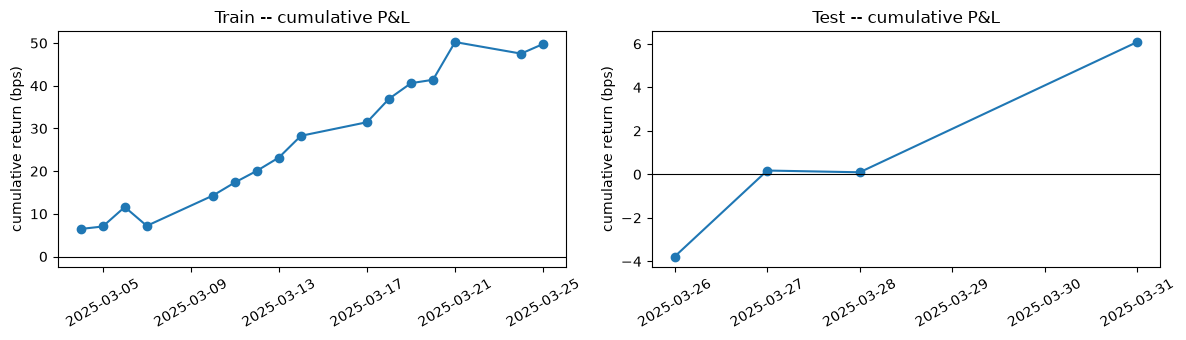

In [9]:
def plot_pnl_track(daily_df, title, ax):
    d = daily_df.sort_values("date").copy()
    d["cumulative_bps"] = d["daily_return_bps"].cumsum()
    ax.plot(d["date"], d["cumulative_bps"], marker="o")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("cumulative return (bps)")
    ax.tick_params(axis="x", rotation=30)


fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_pnl_track(train_daily, "Train -- cumulative P&L", axes[0])
plot_pnl_track(test_daily, "Test -- cumulative P&L", axes[1])
fig.tight_layout()
plt.show()

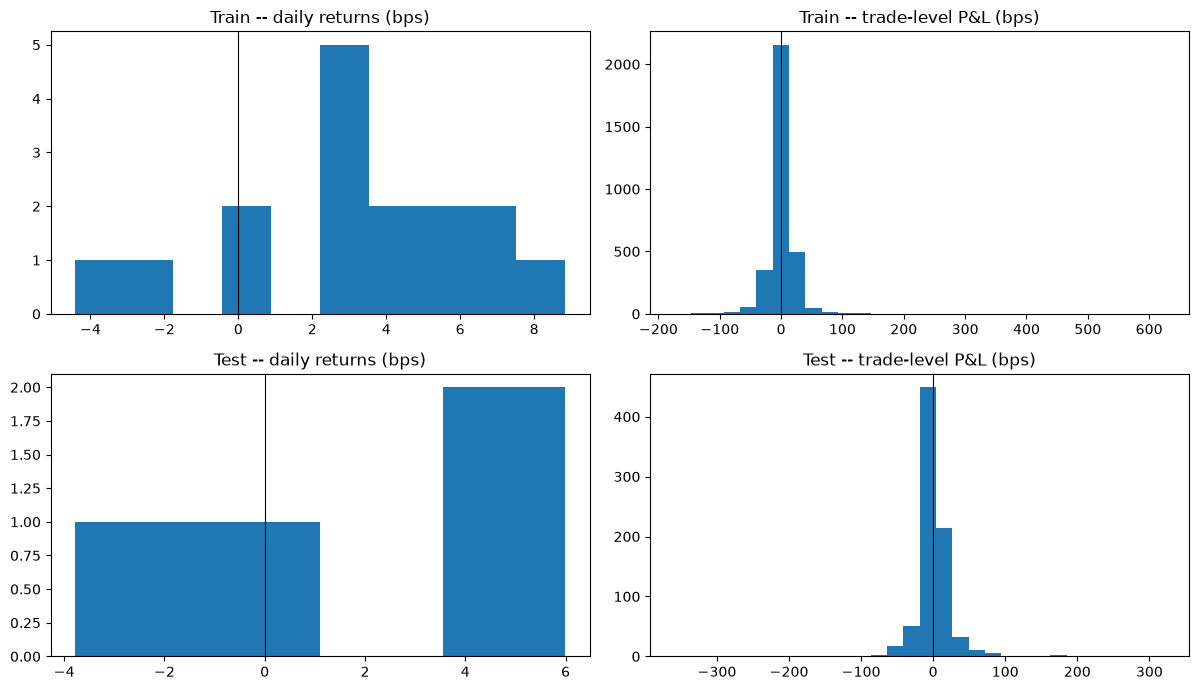

In [10]:
def plot_return_distribution(daily_df, trades_df, title, axes):
    axes[0].hist(daily_df["daily_return_bps"], bins=min(10, len(daily_df)))
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].set_title(f"{title} -- daily returns (bps)")
    axes[1].hist(trades_df["pnl_bps"], bins=30)
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_title(f"{title} -- trade-level P&L (bps)")


fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_return_distribution(train_daily, train_trades, "Train", axes[0])
plot_return_distribution(test_daily, test_trades, "Test", axes[1])
fig.tight_layout()
plt.show()

## Stress testing

Two different things, on purpose:

- **Remove top winners** actually deletes the best-performing trades (globally ranked, pooled
  across both legs and all days) before recomputing daily returns -- it asks "does the edge depend
  on a small number of great trades." Whole days can lose most of their long or short leg if that
  day happened to contain several of the deleted trades.
- **Winsorize** caps the same trade-level P&L distribution at the same percentiles, but keeps every
  trade in the sample (both tails, not just the top) -- it asks "how sensitive are the results to
  outlier magnitude," without the removal test's day-gutting effect.

In [11]:
def remove_top_winners(trades_df, pct):
    threshold = trades_df["pnl_bps"].quantile(1 - pct)
    return trades_to_daily(trades_df[trades_df["pnl_bps"] < threshold])


def winsorize_trades(trades_df, pct):
    lo, hi = trades_df["pnl_bps"].quantile([pct, 1 - pct])
    capped = trades_df.copy()
    capped["pnl_bps"] = capped["pnl_bps"].clip(lo, hi)
    return trades_to_daily(capped)


rows = []
for label, trades in [("train", train_trades), ("test", test_trades)]:
    for pct in [0.01, 0.02, 0.05]:
        d = remove_top_winners(trades, pct)
        rows.append({"period": label, "stress": f"remove top {pct:.0%}", **summary_stats(d).to_dict()})
        d = winsorize_trades(trades, pct)
        rows.append({"period": label, "stress": f"winsorize {pct:.0%}", **summary_stats(d).to_dict()})

stress_table = pd.DataFrame(rows)[["period", "stress", "n_days", "mean_daily_bps", "sharpe_annualized",
                                    "t_stat", "p_value", "hit_rate"]]
print(stress_table.to_string(index=False))

period        stress  n_days  mean_daily_bps  sharpe_annualized    t_stat  p_value  hit_rate
 train remove top 1%      16        0.479528           2.334604  0.588265 0.565107    0.6250
 train  winsorize 1%      16        2.646001          14.958176  3.769106 0.001857    0.8125
 train remove top 2%      16       -0.702021          -3.526850 -0.888683 0.388203    0.5000
 train  winsorize 2%      16        2.276821          13.923689  3.508440 0.003168    0.8125
 train remove top 5%      16       -3.010032         -14.113661 -3.556308 0.002872    0.1875
 train  winsorize 5%      16        2.409037          16.132345  4.064969 0.001016    0.8125
  test remove top 1%       4       -2.276172         -11.010075 -1.387139 0.259491    0.2500
  test  winsorize 1%       4        1.001393           5.461263  0.688054 0.540847    0.5000
  test remove top 2%       4       -3.740523         -26.473399 -3.335335 0.044542    0.0000
  test  winsorize 2%       4        0.504847           3.601385  0.453

## Stress testing -- execution lag

Same idea as `05)`'s lag check: hold the model's long/short selection fixed (it was already
computed above), reprice those same names at 1s/5s/10s after the 15:58:00 signal, and see if the
Sharpe survives. No retraining needed -- only the fill price changes.

In [12]:
def add_seconds_to_clock(clock_str, seconds):
    h, m, s = (int(x) for x in clock_str.split(":"))
    total = h * 3600 + m * 60 + s + seconds
    return f"{total // 3600:02d}:{(total % 3600) // 60:02d}:{total % 60:02d}"


def reprice_at_lag(trades_df, lag_seconds, entry_clock="15:58:00"):
    lag_clock = add_seconds_to_clock(entry_clock, lag_seconds)
    lag_panel = build_snapshot_panel(raw, lag_clock, full_df)
    lag_lookup = lag_panel.set_index(["date", "symbol"])[["realized_buy_bps", "realized_sell_bps"]]

    repriced = trades_df.copy()
    keys = list(zip(repriced["date"], repriced["symbol"]))
    buy_lag = lag_lookup.reindex(keys)["realized_buy_bps"].to_numpy()
    sell_lag = lag_lookup.reindex(keys)["realized_sell_bps"].to_numpy()
    is_long = (repriced["leg"] == "long").to_numpy()
    repriced["pnl_bps"] = np.where(is_long, buy_lag, sell_lag)
    n_missing = int(pd.isna(repriced["pnl_bps"]).sum())
    return trades_to_daily(repriced), n_missing


lag_rows = []
for label, trades in [("train", train_trades), ("test", test_trades)]:
    for lag_seconds in [1, 5, 10]:
        d, n_missing = reprice_at_lag(trades, lag_seconds)
        lag_rows.append({"period": label, "lag_seconds": lag_seconds, "n_missing": n_missing,
                          **summary_stats(d).to_dict()})

lag_table = pd.DataFrame(lag_rows)[["period", "lag_seconds", "n_missing", "mean_daily_bps",
                                     "sharpe_annualized", "t_stat", "p_value", "hit_rate"]]
print(lag_table.to_string(index=False))

period  lag_seconds  n_missing  mean_daily_bps  sharpe_annualized    t_stat  p_value  hit_rate
 train            1          0        2.391348          11.960216  3.013691 0.008726    0.8750
 train            5          0        2.756789          14.075318  3.546647 0.002929    0.8750
 train           10          0        2.653114          13.954888  3.516301 0.003117    0.8125
  test            1          0        1.044490           3.797759  0.478473 0.665020    0.5000
  test            5          0        0.629992           2.666054  0.335891 0.759073    0.5000
  test           10          0       -0.031220          -0.118790 -0.014966 0.988999    0.5000


## Stress testing -- bootstrap Sharpe, drawdown, sub-period stability

Extra checks beyond what was asked for explicitly: a bootstrap confidence interval on Sharpe
(resampling days with replacement -- the honest way to see how much the point estimate should be
trusted given only 16, and especially only 4, days), max drawdown of the cumulative P&L track, and
a first-half-vs-second-half split to check the edge isn't concentrated in a handful of early days.

With `n=4` for test, all three of these are illustrative at best, not reliable estimates -- included
for completeness, not because 4 points support a real bootstrap or a meaningful drawdown statistic.

In [13]:
def bootstrap_sharpe_ci(daily_df, n_boot=5000, seed=0):
    r = daily_df["daily_return_bps"].to_numpy()
    rng = np.random.default_rng(seed)
    boot_sharpes = np.full(n_boot, np.nan)
    for i in range(n_boot):
        sample = rng.choice(r, size=len(r), replace=True)
        if sample.std() > 0:
            boot_sharpes[i] = (sample.mean() / sample.std()) * np.sqrt(252)
    return np.nanpercentile(boot_sharpes, [5, 50, 95])


def max_drawdown(daily_df):
    cum = daily_df.sort_values("date")["daily_return_bps"].cumsum()
    return (cum - cum.cummax()).min()


def subperiod_stability(daily_df):
    d = daily_df.sort_values("date").reset_index(drop=True)
    mid = len(d) // 2
    first, second = d.iloc[:mid], d.iloc[mid:]
    return {
        "first_half_mean_bps": first["daily_return_bps"].mean(),
        "second_half_mean_bps": second["daily_return_bps"].mean(),
        "first_half_sharpe_ann": (first["daily_return_bps"].mean() / first["daily_return_bps"].std()) * np.sqrt(252),
        "second_half_sharpe_ann": (second["daily_return_bps"].mean() / second["daily_return_bps"].std()) * np.sqrt(252),
    }


for label, daily in [("train", train_daily), ("test", test_daily)]:
    ci = bootstrap_sharpe_ci(daily)
    mdd = max_drawdown(daily)
    sub = subperiod_stability(daily)
    print(f"{label}: bootstrap sharpe_ann 5/50/95% = {ci[0]:.2f} / {ci[1]:.2f} / {ci[2]:.2f}  "
          f"| max_drawdown_bps = {mdd:.2f}")
    print(f"  {label} sub-period: {sub}")

train: bootstrap sharpe_ann 5/50/95% = 7.65 / 15.82 / 31.01  | max_drawdown_bps = -4.41
  train sub-period: {'first_half_mean_bps': np.float64(2.8993519095883222), 'second_half_mean_bps': np.float64(3.325048120974209), 'first_half_sharpe_ann': np.float64(12.700243718234487), 'second_half_sharpe_ann': np.float64(15.40588844453825)}
test: bootstrap sharpe_ann 5/50/95% = -9.96 / 6.42 / 77.58  | max_drawdown_bps = -0.08
  test sub-period: {'first_half_mean_bps': np.float64(0.08748600330595635), 'second_half_mean_bps': np.float64(2.954178451201005), 'first_half_sharpe_ann': np.float64(0.2539824405549223), 'second_half_sharpe_ann': np.float64(10.928462784618524)}


## Final: test set only

Everything above in one place, isolated to the held-out test period, with no stress-test
comparisons -- the bottom-line answer to "does the winning recipe (MLP, quintile, 15:58:00) hold up
on data it has never seen.

Test set: 2025-03-26 to 2025-03-31 (4 trading days, 792 trade-level rows)

label                    test
n_days                      4
mean_daily_bps       1.520832
std_daily_bps        4.340975
sharpe_daily         0.350343
sharpe_annualized     5.56153
t_stat               0.700687
p_value              0.533954
hit_rate                  0.5
cumulative_bps       6.083329
skew                -0.232388
kurtosis             -1.46178
min_bps             -3.779033
median_bps           1.936926
max_bps              5.988509


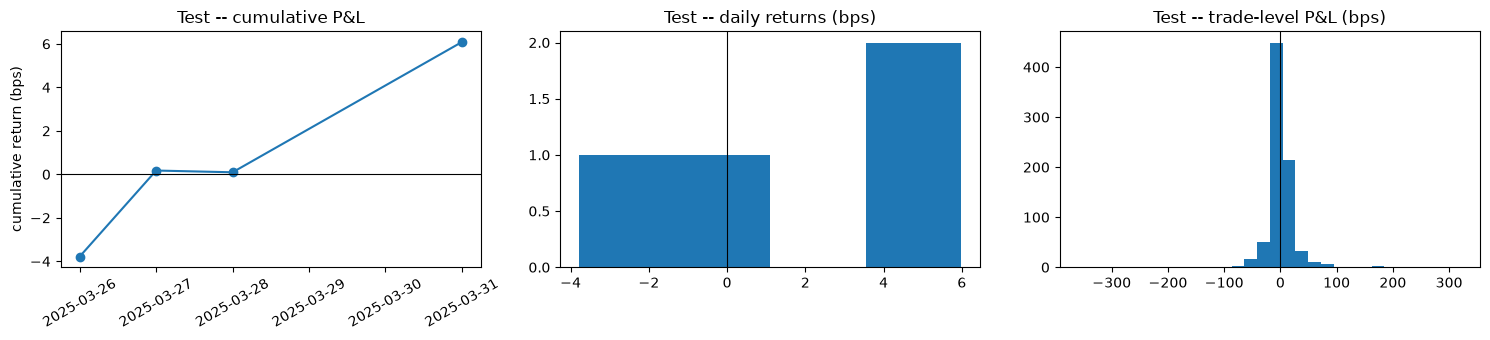


Daily returns (bps): [-3.78, 3.95, -0.08, 5.99]
Sharpe (annualized): 5.56
t-stat / p-value: 0.70 / 0.534
Hit rate: 50%


In [14]:
print(f"Test set: {test_daily['date'].min().date()} to {test_daily['date'].max().date()} "
      f"({len(test_daily)} trading days, {len(test_trades)} trade-level rows)\n")

test_metrics = summary_stats(test_daily, "test")
print(test_metrics.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
plot_pnl_track(test_daily, "Test -- cumulative P&L", axes[0])
plot_return_distribution(test_daily, test_trades, "Test", axes[1:3])
fig.tight_layout()
plt.show()

print(f"\nDaily returns (bps): {test_daily.sort_values('date')['daily_return_bps'].round(2).tolist()}")
print(f"Sharpe (annualized): {test_metrics['sharpe_annualized']:.2f}")
print(f"t-stat / p-value: {test_metrics['t_stat']:.2f} / {test_metrics['p_value']:.3f}")
print(f"Hit rate: {test_metrics['hit_rate']:.0%}")